# 1 · Full Research Cycle

A complete pass: **data → indicators → strategy/rules → SL·TP config → simulate → stats →
plots → interactive chart → save**. Run top-to-bottom; edit the config cells to taste.


## 0 · Start / setup


In [2]:
import sys, os, json, warnings; warnings.filterwarnings('ignore')
try:
    import quant
except ModuleNotFoundError:
    sys.path.insert(0, os.path.abspath('..'))
    import quant

from pathlib import Path
from quant.data import get_ohlcv
from quant.indicators import add_emas, add_rsi, add_macd
from quant.engine import BacktestConfig, TakeProfit, Signals, run_backtest
from quant.strategies import EmaRibbon
from quant import signals as S
from quant import reporting as R, analytics as A
from quant.viz import (ResearchChart, equity_chart, equity_and_drawdown,
                       monthly_returns_heatmap, hour_weekday_heatmap)
print('quant', quant.__version__)

quant 0.1.0


## 1 · Select ticker & data source
`source='binance'` (PAXGUSDT/XAUTUSDT/BTCUSDT…) or `source='dukascopy'` (true spot **XAUUSD**,
needs `pip install dukascopy-python`).


In [4]:
SYMBOL = 'PAXGUSDT'      # e.g. 'XAUUSD' with source='dukascopy'
SOURCE = 'binance'       # 'binance' | 'dukascopy'
MARKET = 'spot'

## 2 · Timeframe & date range
Only this range is pulled; missing candles download incrementally, then cache.


In [8]:
TF   = '1m'
START, END = '2025-01-01', '2026-07-23'
TZ   = 'UTC'            # display tz for charts & session/time filters

df = get_ohlcv(SYMBOL, TF, start=START, end=END, source=SOURCE, market=MARKET, tz=TZ)
print(f'{len(df):,} bars  {df.open_time.min()} -> {df.open_time.max()}')
df.tail(3)

[04:15:55] INFO | quant.data | cache HIT  binance PAXGUSDT 1m -> pushdown load


742,469 bars  2025-01-01 00:00:00+00:00 -> 2026-05-31 14:28:00+00:00


,open_time,open,high,low,close,volume,quote_volume,num_trades,taker_buy_base,taker_buy_quote,t
742466,2026-05-31 14:26:00+00:00,4532.45,4532.46,4532.45,4532.46,0.0069,31.273943,3,0.0038,17.223348,2026-05-31 14:26:00+00:00
742467,2026-05-31 14:27:00+00:00,4532.45,4532.45,4532.45,4532.45,0.1914,867.510930,5,0.0000,0.000000,2026-05-31 14:27:00+00:00
742468,2026-05-31 14:28:00+00:00,4532.45,4532.45,4532.45,4532.45,0.0000,0.000000,0,0.0000,0.000000,2026-05-31 14:28:00+00:00


## 3 · Indicators
Add any indicator columns you want available to rules/plots (vectorized; safe to add many).


In [5]:
df = add_emas(df, [20, 50, 100, 200])   # ema_20, ema_50, ema_100, ema_200
df = add_rsi(df, 14)                     # rsi_14
[c for c in df.columns if c.startswith(('ema_', 'rsi'))]

['ema_20', 'ema_50', 'ema_100', 'ema_200', 'rsi_14']

## 4 · Strategy — pick ONE of the two styles below


### 4a · Built-in strategy (one line)
Buy when price crosses EMA(20) **and** stays above EMA(50) for 3 candles; exit on the reverse cross.


In [6]:
strategy = EmaRibbon(fast=20, slow=50, confirm_n=3)

### 4b · OR define your own buy/sell open & close rules inline
Compose vectorized primitives into entry/exit boolean arrays. This is the raw 'rules' interface.
(Run this cell to override `strategy` with a custom-signals runner; skip it to use 4a.)


In [14]:
# BUY (open long)  : close crosses above EMA20  AND close has been above EMA50 for 3 bars
# SELL (close long): close crosses below EMA20   (or RSI overbought)
open_long  = S.all_of(S.cross_up(df, 'close', 'ema_200'),
                      S.last_all_above(df, 'close', 'ema_50', 2))
close_long = S.any_of(S.cross_down(df, 'close', 'ema_50'))
custom_signals = Signals(entry_long=open_long, exit_long=close_long)
print('buy signals:', int(open_long.sum()), '| sell signals:', int(close_long.sum()))

buy signals: 1650 | sell signals: 7445


## 5 · Backtest config — SL / TP / costs / sizing
See `BacktestConfig` docstring for every field. Example: 0.6%% stop, laddered TP (50%% at 1R then
the rest at 2R with breakeven), risk 1%% of equity per trade, gold spread + commission.


In [15]:
cfg = BacktestConfig(
    initial_cash=10_000,
    fee_bps=0, commission_per_lot=0.0, spread=0.20,   # Exness-style: spread + (usually 0) commission
    slippage_bps=1.0,
    exit_enabled=True,
    sl_mode='entry_pct', sl_value=0.6,                # or sl_mode='ref_col', sl_ref_long_col='swing_last_low'
    take_profits=(TakeProfit('rr', 1.0, close_pct=50, move_stop_mode='breakeven'),
                  TakeProfit('rr', 2.0, close_pct=100)),
    sizing_mode='risk_pct_equity', sizing_value=1.0,
    # leverage (optional): margin_enabled=True, leverage=500, contract_size=100, sizing_mode='lots', sizing_value=0.1,
)

## 6 · Run the simulation & see stats


In [16]:
USE_CUSTOM_RULES = False   # True -> use the 4b custom signals; False -> use the 4a strategy
if USE_CUSTOM_RULES:
    res = run_backtest(df, custom_signals, cfg)
else:
    res = strategy.backtest(df, cfg)
R.print_summary(res, df=df)
res.stats

[08:29:07] INFO | quant.engine | backtest done | bars=216,001 trades=3,262 final_cash=4645.02 return=-53.55% dd=53.62% | 11.3 ms


 PERFORMANCE SUMMARY
  Total return %                     -53.55
  Final cash                       4,645.02
  Trades                               3262
  Win rate %                          16.89
  Profit factor                        0.53
  Expectancy / trade                -1.6416
  Sharpe                             -17.96
  Sortino                             -8.40
  Calmar                              -3.47
  Max drawdown %                      53.62
  Recovery factor                     -1.00
  Avg bars held                           8
  Total fees                           0.00

  Best weekday: Sat (pnl=-432.59, win=12.2%)
  Best session: tokyo (pnl=-1975.55, n=1300)


{'initial_cash': 10000.0,
 'final_cash': 4645.02404970474,
 'total_return_pct': -53.5497595029526,
 'max_drawdown_pct': 53.61883059927529,
 'sharpe': -17.95980465859194,
 'sortino': -8.40249523393667,
 'calmar': -3.4721998722033973,
 'total_pnl': -5354.975950295314,
 'num_trades': 3262.0,
 'num_winners': 551.0,
 'num_losers': 2711.0,
 'num_breakeven': 0.0,
 'win_rate_pct': 16.891477621091354,
 'loss_rate_pct': 83.10852237890865,
 'gross_profit': 6143.713809528555,
 'gross_loss': 11498.68975982387,
 'profit_factor': 0.5342968579772049,
 'avg_pnl': -1.641623528600648,
 'median_pnl': -2.862246136431926,
 'avg_winner': 11.150115806766888,
 'avg_loser': -4.2414938250918,
 'largest_winner': 79.51843895534702,
 'largest_loser': -58.566866712208544,
 'expectancy_per_trade': -1.641623528600648,
 'expectancy_pct_initial_cash': -0.01641623528600648,
 'avg_return_pct': -0.023430128667516453,
 'avg_bars_held': 8.335683629675046,
 'max_consecutive_wins': 4.0,
 'max_consecutive_losses': 29.0,
 'recov

## 7 · Stat plots


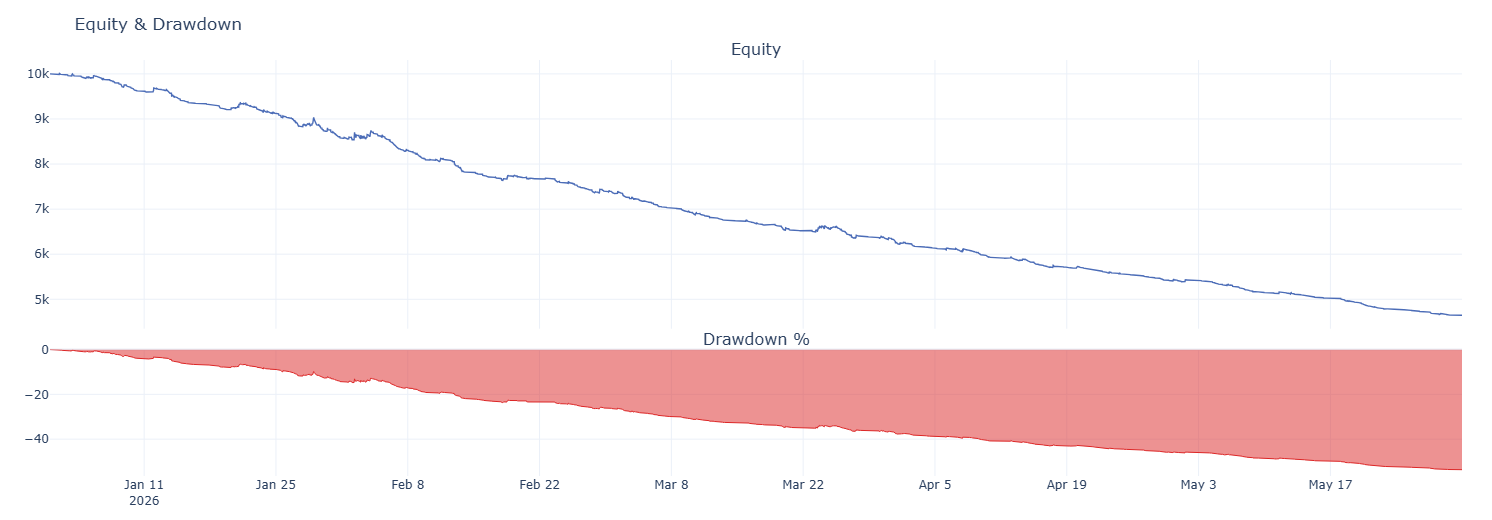

In [17]:
equity_and_drawdown(res.equity_curve)

In [11]:
monthly_returns_heatmap(A.monthly_returns(res.equity_curve))

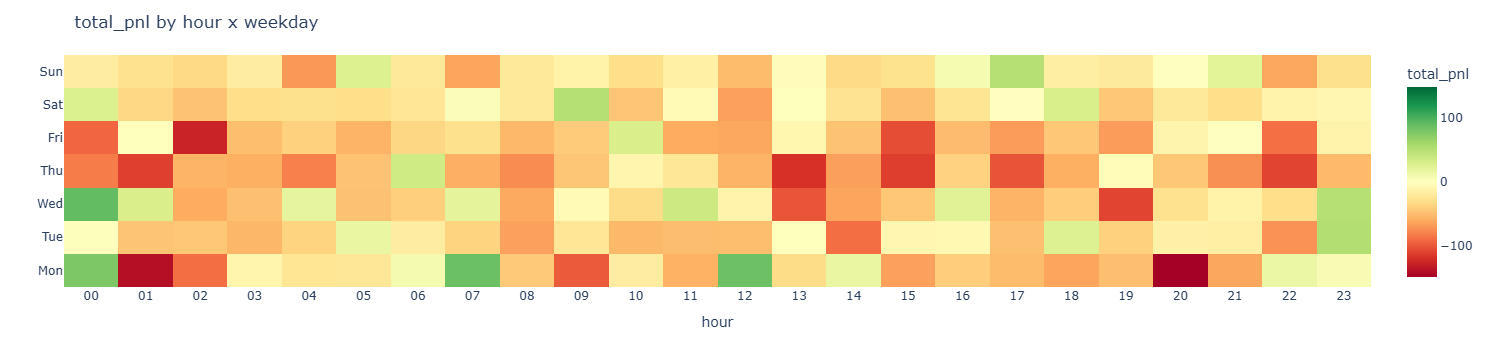

In [12]:
hour_weekday_heatmap(res.trades, metric='total_pnl')   # when does it make/lose money?

## 8 · Interactive price + indicator chart with trades
Smooth at millions of candles. **Click legend entries to toggle** any line / markers / candles.
Pan & zoom reloads higher resolution for the visible window only.


In [13]:
ch = ResearchChart(df, candles=True)
ch.add_ema(20); ch.add_ema(50); ch.add_ema(200)
ch.add_trades(res.trades)
ch.show()

FigureWidgetResampler({
    'data': [{'line': {'width': 1.1},
              'mode': 'lines',
              'name': '<b style="color:sandybrown">[R]</b> EMA20 <i style="color:#fc9944">~1h</i>',
              'type': 'scattergl',
              'uid': '39377a8b-53fc-4ef8-aeca-0c5184b5e298',
              'x': array([Timestamp('2026-01-01 00:00:00+0000', tz='UTC'),
                          Timestamp('2026-01-01 00:19:00+0000', tz='UTC'),
                          Timestamp('2026-01-01 02:53:00+0000', tz='UTC'), ...,
                          Timestamp('2026-05-30 21:40:00+0000', tz='UTC'),
                          Timestamp('2026-05-30 22:25:00+0000', tz='UTC'),
                          Timestamp('2026-05-31 00:00:00+0000', tz='UTC')],
                         shape=(2500,), dtype=object),
              'y': {'bdata': ('AAAAAAAA+H95TN1KdfSwQCCI+Ff48L' ... '7DyKuxQB4lKy3vrLFAJoKmh3ursUA='),
                    'dtype': 'f8'}},
             {'line': {'width': 1.1},
              'mode': '

## 9 · Save results
Writes trades, equity, stats, and a standalone HTML report to `reports/<run>/`.


In [ ]:
run_name = f'{SYMBOL}_{TF}_{START}_{END}'
out = Path('reports') / run_name; out.mkdir(parents=True, exist_ok=True)
res.trades.to_csv(out/'trades.csv', index=False)
res.equity_curve.to_csv(out/'equity.csv', index=False)
json.dump(res.stats, open(out/'stats.json','w'), indent=2, default=float)
R.to_html(res, str(out/'report.html'), df=df, price_df=df, title=run_name)
print('saved ->', out.resolve())